Looking at what methods to analyse this data will actually work

In [1]:
from recieveData import get_data

df = get_data()
display(df)

,game_id,game_name,category,genre,sub_genre,created,id,global_rank,global_rank_shift_1d,global_rank_shift_1w,...,avg_ccu_14d,momentum_1d,momentum_1w,momentum_1m,avg_session,favorites,rating,up_votes,down_votes,extract_date
0,475e1b5d-139f-41bc-9632-dec98d51822f,[⛩️] +1 Katana Evolution,Top Moving,Simulation,Incremental Simulator,2026-06-11,27e4b915-ac62-4f43-ba23-d5c8d2aa557d,9345.0,9946,0,...,6.0,Rising,None,NaN,10.4,12856,0.8257,3206,677,2026-07-30
1,ee5eef72-2334-4afe-80d6-1668f05efaf4,Squishy Dumpling Empire 🥟,Top Moving,Simulation,Tycoon,2026-06-08,4b776470-4c6a-425d-a035-fb451a3ce940,9925.0,7681,0,...,10.0,Rising,None,NaN,14.2,4889,0.9792,6679,142,2026-07-30
2,e2cee74d-93ab-4f51-a83d-4214fcb7b455,SIKAYD: VERITY RP,Top Moving,Roleplay & Avatar Sim,Morph Roleplay,2026-06-25,bbc3712d-cf17-423d-93a6-5ba5880f5608,5733.0,6433,0,...,69.0,Surging,None,NaN,7.4,22257,0.8457,4123,752,2026-07-30
3,dc8b8720-7d9a-41be-9e40-bcd5ea2a72ce,[⚽️] Math for Soccer Cards!,Top Moving,NaN,NaN,2026-06-13,1e23a207-1e2a-492e-a55b-2e83af62d36c,5476.0,5586,0,...,43.0,Surging,None,NaN,8.1,3297,0.8849,1437,187,2026-07-30
4,8d016425-2712-4a56-9f05-33a0c80380b2,Лагерь РП 🌞,Top Moving,Roleplay & Avatar Sim,NaN,2024-07-17,7b9644a1-6314-4e94-a38e-32eaa433030b,4027.0,5276,0,...,135.0,Surging,None,Rising,15.4,7981,0.7919,2219,583,2026-07-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521,c7325854-dda1-4f90-8710-ff75854713ca,Tower Creator,Top by Session,Simulation,Sandbox,2022-01-26,eac64d4b-06ac-4bed-8fae-abac3620079f,2419.0,-78,0,...,470.0,Stable,None,Rising,29.1,40378,0.8103,15339,3591,2026-07-30
522,4553d0b9-cb59-423f-81f1-87a21a307eba,Pixel Quest [RPG],Top by Session,RPG,Open World & Survival RPG,2025-03-30,66fc0f34-bdec-4ddf-a190-f1220751b0f6,3052.0,-485,0,...,477.0,Fading,None,Dropping,29.1,322784,0.8722,63756,9341,2026-07-30
523,aea70eb1-9576-482a-9bca-9ac4f63ee1fe,[WAVE 50] Toy Defense🧸,Top by Session,Strategy,Tower Defense,2020-08-24,c463e1c6-dcf3-417e-95c9-46ab5ad643fd,5342.0,-91,0,...,139.0,Stable,None,Stable,29.0,167231,0.8607,135504,21932,2026-07-30
524,9b929b14-7631-450e-ab23-fe17ac5eebd7,Shindo Life [249],Top by Session,RPG,Action RPG,2020-01-20,1b2ca9f4-2c1c-427c-b267-c8cbf9b4dd3f,480.0,-26,0,...,3695.0,Stable,None,Fading,28.8,3044723,0.9385,2214526,145062,2026-07-30


In [2]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

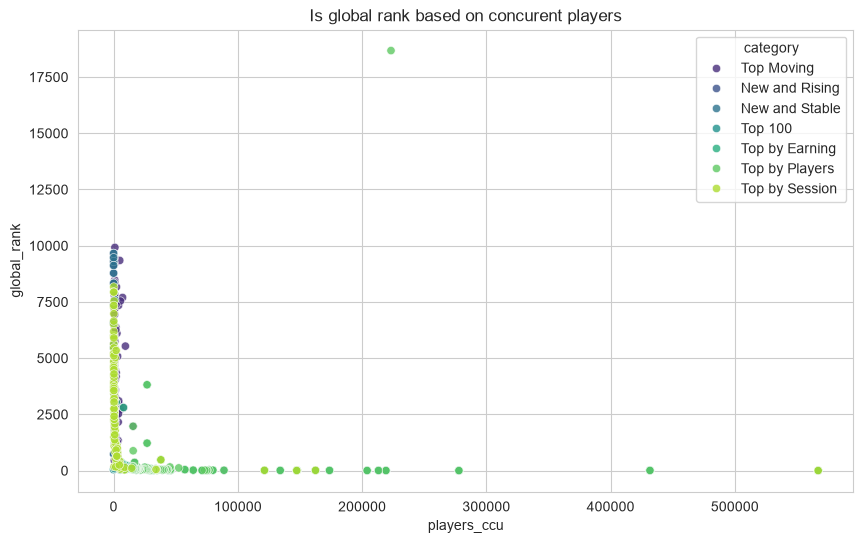

In [3]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='players_ccu', y='global_rank', hue='category', palette='viridis', alpha=0.8)
plt.title("Is global rank based on concurent players")
plt.show()

The scatterplot shows that the concurrent player count despite only being time shot from when the data was extracted does show that almost all the games with a player count above 100,000 were in the top 2500 games on global rank, all but one which has a global rank above 17,500. In conculsion, the players_ccu rank metric is a good indication that a game will rank highly on Rotrends. Maybe the higher average_ccu over a period of time have a better correlation with global rankings.

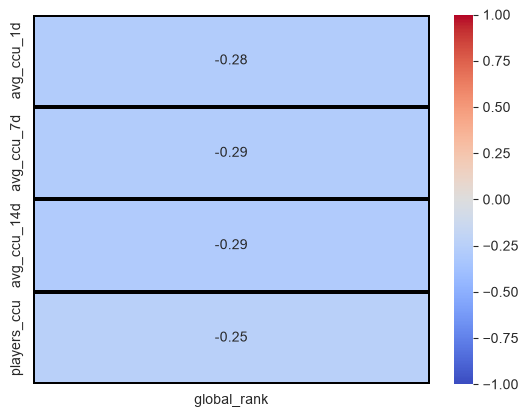

In [4]:
ccuColumns = ['avg_ccu_1d', 'avg_ccu_7d', 'avg_ccu_14d', 'players_ccu', 'global_rank']

target_corr = df[ccuColumns].corr()[['global_rank']].drop(index='global_rank')

sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=1.5, linecolor='black')
plt.show()

This does show that the averages did get a better result in correlation to the global rank, I understand that the negative is due to the fact that the lower the number for global rank should mean a higher CCU. And this does also show that the highest correlation is the 14d average. Next, I'll see if there is any other major correlations from the other metrics to the global rank.

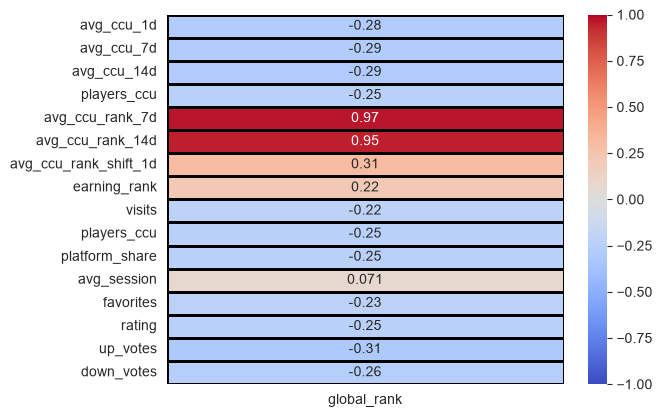

In [5]:
allQuantativeMetrics = ['avg_ccu_1d', 'avg_ccu_7d', 'avg_ccu_14d', 'players_ccu', 'avg_ccu_rank_7d', 'avg_ccu_rank_14d', 'avg_ccu_rank_shift_1d', 'earning_rank', 'visits', 'players_ccu', 'platform_share', 'avg_session', 'favorites', 'rating', 'up_votes', 'down_votes', 'global_rank']

all_corr = df[allQuantativeMetrics].corr()[['global_rank']].drop(index='global_rank')
sns.heatmap(all_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=1, linecolor='black')
plt.show()

From this heatmap, it is clear that the global rank has the highest correlation to the average CCU rank. Means they should be calculated very similar. Very surprised about the avg_session as this is a valued metric to Roblox in terms of the front page algorithm as Roblox likes to push games to the front page if they have good average session time, player retention and CCU. Rotrends is unable to track retention as this is only available to roblox and the game owner.

Moving away from looking at how Rotrends analysis their rankings:
Now I will look at what keywords in games are being used: A method I was suggested to use to count for words was the Count Vectorizer

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

titles = df['game_name'].dropna().tolist()

vectoriser = CountVectorizer(ngram_range=(1,2), stop_words='english')

matrix = vectoriser.fit_transform(titles)

wordCount = pd.DataFrame({'Phrase': vectoriser.get_feature_names_out(), 'Count': matrix.toarray().sum(axis=0)})

display(wordCount.sort_values(by='Count', ascending=False).head(25))

,Phrase,Count
1209,upd,45
57,anime,29
999,simulator,26
927,rp,23
421,escape,20
1151,tower,19
1238,update,15
1269,vs,15
1187,tycoon,15
623,keyboard,14


Now looking through the sklearn documentation I see another type of word counter but this penalises words that appear in almost every game, this could be used to help identify unique trending games

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

Tvectoriser = TfidfVectorizer()

T_matrix = Tvectoriser.fit_transform(titles)
T_wordCount = pd.DataFrame({'Phrase': Tvectoriser.get_feature_names_out(), 'Count': T_matrix.toarray().sum(axis=0)})

display(T_wordCount.sort_values(by='Count', ascending=False).head(25))

,Phrase,Count
656,upd,15.972264
38,anime,11.128184
557,simulator,10.420981
520,rp,9.773273
629,tower,8.245607
616,the,8.148517
228,escape,8.080728
645,tycoon,7.649957
626,to,7.078568
658,update,6.723929
